# Experiment 3: Regression Analysis using Linear and Regularized Models

**Course:** ICS1512 – Machine Learning Algorithms Laboratory
**Dataset:** Kaggle – Predict Loan Amount Data

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import time
import warnings
warnings.filterwarnings("ignore")   


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load the Dataset



In [ ]:
# NOTE: You can change this path if your dataset is stored elsewhere
DATASET_PATH = r"C:\Users\farih\Documents\ML\Experiment 3\Exp 3 Dataset\train.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(DATASET_PATH)

# Confirm that the dataset has loaded correctly
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")


Dataset loaded successfully with 30000 rows and 24 columns.


## 3. Display Dataset Information



In [19]:
print("Shape of dataset (rows, columns):", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nData types of each column:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())


Shape of dataset (rows, columns): (30000, 24)

Column names:
['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score', 'No. of Defaults', 'Has Active Credit Card', 'Property ID', 'Property Age', 'Property Type', 'Property Location', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']

First 5 rows of the dataset:


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28



Data types of each column:
Customer ID                     object
Name                            object
Gender                          object
Age                              int64
Income (USD)                   float64
Income Stability                object
Profession                      object
Type of Employment              object
Location                        object
Loan Amount Request (USD)      float64
Current Loan Expenses (USD)    float64
Expense Type 1                  object
Expense Type 2                  object
Dependents                     float64
Credit Score                   float64
No. of Defaults                  int64
Has Active Credit Card          object
Property ID                      int64
Property Age                   float64
Property Type                    int64
Property Location               object
Co-Applicant                     int64
Property Price                 float64
Loan Sanction Amount (USD)     float64
dtype: object

Missing values in eac

## 4. Data Preprocessing


In [20]:
possible_target_names = [
    "LoanAmount", "Loan_Amount", "loan_amount", "LoanAmountRequested",
    "Loan Amount", "loan_amount_requested", "Amount"
]

TARGET_COLUMN = None
for name in possible_target_names:
    if name in df.columns:
        TARGET_COLUMN = name
        break

if TARGET_COLUMN is None:
    amount_cols = [c for c in df.columns if "amount" in c.lower()]
    if amount_cols:
        TARGET_COLUMN = amount_cols[0]



print("Target column detected:", TARGET_COLUMN)
assert TARGET_COLUMN is not None, "Please set TARGET_COLUMN manually to the loan amount column name."


id_like_cols = [c for c in df.columns if "id" == c.lower() or c.lower().endswith("_id")]
df_processed = df.drop(columns=id_like_cols, errors="ignore").copy()


feature_columns = [c for c in df_processed.columns if c != TARGET_COLUMN]
categorical_cols = df_processed[feature_columns].select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = df_processed[feature_columns].select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


# Fill missing numeric values with the median of that column
for col in numerical_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# Fill missing categorical values with the most frequent value (mode)
for col in categorical_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

# Fill missing target values with the median target value
df_processed[TARGET_COLUMN] = df_processed[TARGET_COLUMN].fillna(df_processed[TARGET_COLUMN].median())

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le

print("\nMissing values after cleaning:")
print(df_processed.isnull().sum().sum(), "total missing values remaining.")

X = df_processed[feature_columns]
y = df_processed[TARGET_COLUMN]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("\nFinal shape of feature matrix X:", X_scaled.shape)
print("Final shape of target vector y:", y.shape)

display(X_scaled.head())


Target column detected: Loan Amount Request (USD)
Categorical columns: ['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location']
Numerical columns: ['Age', 'Income (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property ID', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']

Missing values after cleaning:
0 total missing values remaining.

Final shape of feature matrix X: (30000, 23)
Final shape of target vector y: (30000,)


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Current Loan Expenses (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,0.355706,-0.631679,-1.007092,0.991451,-0.061266,0.305833,0.834973,1.569338,0.142149,-0.660358,...,0.992493,-0.490502,-1.126689,0.846998,-0.060969,1.376731,-1.214540,0.076982,-0.126419,0.148002
1,0.124304,-1.581420,0.992958,-0.504355,0.229972,0.305833,0.834973,0.027732,0.142149,0.392886,...,0.578136,-0.490502,1.299777,0.368086,0.230298,-0.411309,-1.214540,0.076982,-0.822772,-0.209288
2,0.410207,1.107993,-1.007092,1.552379,-0.152389,-3.269763,-0.686548,0.027732,0.142149,-0.946193,...,1.330799,-0.490502,1.299777,0.152923,-0.152102,-0.411309,1.283229,0.063579,-0.634103,-0.230044
3,-0.456511,1.715943,-1.007092,1.552379,-0.033357,-3.269763,-0.686548,0.027732,-1.762481,-0.422775,...,1.324379,2.038728,1.299777,1.346732,-0.032979,-0.411309,0.034344,0.076982,-0.110298,0.177886
4,-0.693802,-1.710054,-1.007092,-0.566680,0.004480,0.305833,0.834973,-0.486137,0.142149,0.374693,...,0.080879,2.038728,-1.126689,0.739417,0.004783,1.376731,0.034344,0.076982,0.821057,0.552492


## 5. Exploratory Data Analysis (EDA)


Summary statistics:


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Current Loan Expenses (USD),...,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD),Loan Amount Request (USD)
count,3.000000e+04,30000.000000,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,...,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,30000.000000
mean,2.368476e-19,0.000000,-1.103710e-16,-1.042129e-16,1.752672e-17,1.387927e-16,1.042129e-17,-1.800042e-17,-3.126388e-17,-8.479143e-17,...,3.943512e-17,1.323978e-16,-6.915949e-17,8.052818e-18,3.931670e-17,-5.305386e-17,-2.368476e-18,1.752672e-16,9.426534e-17,88826.333855
std,1.000017e+00,1.000017,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,...,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,59536.949605
min,-1.731993e+00,-1.731993,-1.007092e+00,-1.376908e+00,-2.112649e-01,-3.269763e+00,-1.827689e+00,-2.027743e+00,-1.762481e+00,-5.787773e+00,...,-4.905020e-01,-1.126689e+00,-1.738431e+00,-2.109841e-01,-1.305329e+00,-1.214540e+00,-1.332545e+01,-1.419151e+00,-1.011320e+00,6048.240000
25%,-8.659965e-01,-0.865997,-1.007092e+00,-9.406314e-01,-7.956497e-02,3.058326e-01,-1.447309e+00,-4.861368e-01,1.421489e-01,-6.290369e-01,...,-4.905020e-01,-1.126689e+00,-8.708376e-01,-7.864286e-02,-1.305329e+00,-1.214540e+00,7.698176e-02,-7.609733e-01,-9.904923e-01,41177.755000
50%,0.000000e+00,0.000000,9.929581e-01,-5.752621e-03,-3.335734e-02,3.058326e-01,8.349727e-01,2.773178e-02,1.421489e-01,-1.057848e-01,...,-4.905020e-01,8.654395e-02,7.167366e-03,-3.297946e-02,-4.113088e-01,3.434433e-02,7.698176e-02,-2.326728e-01,-2.564186e-01,75128.075000
75%,8.659965e-01,0.865997,9.929581e-01,9.291261e-01,2.901157e-02,3.058326e-01,8.349727e-01,5.416004e-01,1.421489e-01,4.933296e-01,...,-4.905020e-01,1.299777e+00,8.643500e-01,2.742982e-02,4.827112e-01,1.283229e+00,7.698176e-02,5.037098e-01,5.473890e-01,119964.605000
max,1.731993e+00,1.731993,9.929581e-01,1.552379e+00,1.711718e+02,3.058326e-01,8.349727e-01,2.340141e+00,2.046779e+00,1.422390e+01,...,2.038728e+00,1.299777e+00,1.725003e+00,1.711900e+02,1.376731e+00,1.283229e+00,7.698176e-02,1.011467e+01,9.056698e+00,621497.820000


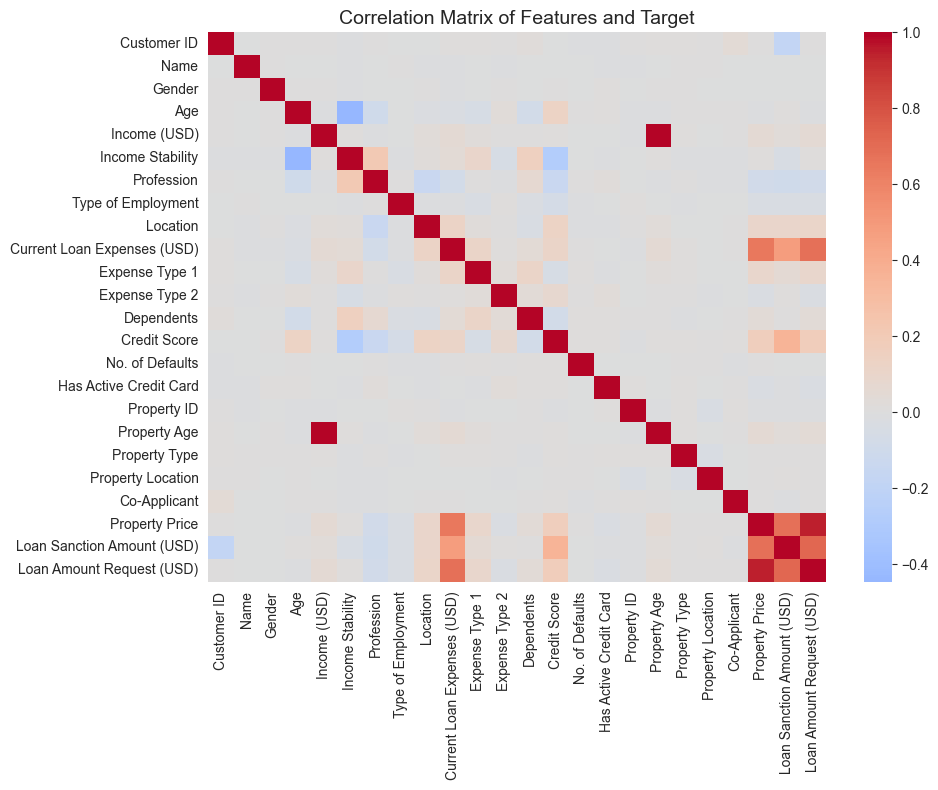


Feature correlation with target (sorted):
Property Price                 0.948350
Loan Sanction Amount (USD)     0.721181
Current Loan Expenses (USD)    0.680451
Credit Score                   0.173332
Location                       0.103902
Expense Type 1                 0.096134
Income (USD)                   0.045981
Property Age                   0.045425
Dependents                     0.039394
Income Stability               0.014013
Property Location              0.005710
Property Type                  0.003802
Customer ID                    0.002057
Co-Applicant                   0.001864
Gender                         0.000107
No. of Defaults                0.000088
Name                          -0.004154
Property ID                   -0.008426
Age                           -0.010450
Expense Type 2                -0.023596
Has Active Credit Card        -0.026222
Type of Employment            -0.030800
Profession                    -0.085669
Name: Loan Amount Request (USD), dtyp

In [21]:
eda_df = X_scaled.copy()
eda_df[TARGET_COLUMN] = y.values

print("Summary statistics:")
display(eda_df.describe())

# Correlation matrix
correlation_matrix = eda_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Features and Target", fontsize=14)
plt.tight_layout()
plt.show()

target_correlation = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
print("\nFeature correlation with target (sorted):")
print(target_correlation)


## 6. Target Variable Distribution Plot



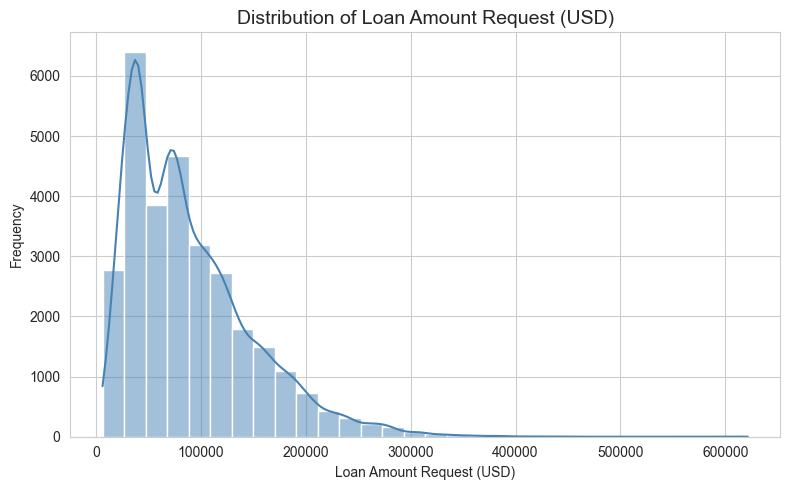

Mean Loan Amount Request (USD): 88826.33
Median Loan Amount Request (USD): 75128.07
Standard deviation: 59536.95


In [22]:
# Plot the distribution of the target variable (Loan Amount)
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True, bins=30, color="steelblue")
plt.title(f"Distribution of {TARGET_COLUMN}", fontsize=14)
plt.xlabel(TARGET_COLUMN)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Mean {TARGET_COLUMN}: {y.mean():.2f}")
print(f"Median {TARGET_COLUMN}: {y.median():.2f}")
print(f"Standard deviation: {y.std():.2f}")


## 7. Feature vs Target Scatter Plots


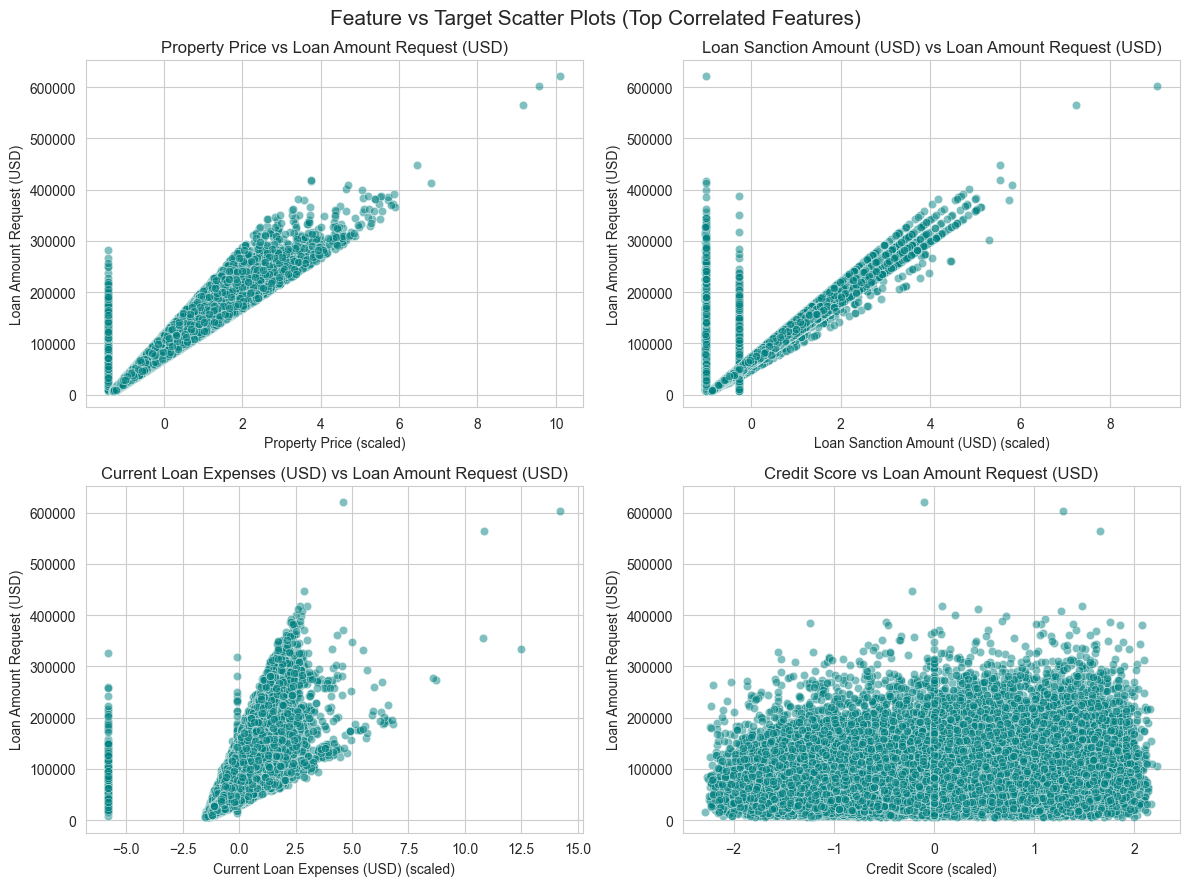

In [23]:
top_features = target_correlation.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.scatterplot(x=X_scaled[feature], y=y, ax=axes[i], alpha=0.5, color="teal")
    axes[i].set_title(f"{feature} vs {TARGET_COLUMN}", fontsize=12)
    axes[i].set_xlabel(f"{feature} (scaled)")
    axes[i].set_ylabel(TARGET_COLUMN)

plt.suptitle("Feature vs Target Scatter Plots (Top Correlated Features)", fontsize=15)
plt.tight_layout()
plt.show()


## 8. Train-Test Split


In [24]:
# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (24000, 23)
Testing set shape: (6000, 23)


## 9. Train Linear Regression Model


In [25]:
# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model and measure training time
start_time = time.time()
linear_model.fit(X_train, y_train)
linear_train_time = time.time() - start_time

# Make predictions on training and test data
y_train_pred_linear = linear_model.predict(X_train)
y_test_pred_linear = linear_model.predict(X_test)

print(f"Linear Regression trained in {linear_train_time:.4f} seconds.")
print("Sample predictions on test set:", y_test_pred_linear[:5])


Linear Regression trained in 0.0131 seconds.
Sample predictions on test set: [ 55001.61744195  79391.60709027 124476.66032706 125453.48616995
  48196.50043019]


## 10. Evaluate Linear Regression


In [26]:
# Create a dictionary to store results of all models (used throughout the notebook)
results = {}

def evaluate_model(name, y_true, y_pred, train_time):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Training Time (s)": train_time
    }

    print(f"--- {name} Evaluation (Test Set) ---")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"Training Time: {train_time:.4f} seconds")

# Evaluate Linear Regression on the test set
evaluate_model("Linear Regression", y_test, y_test_pred_linear, linear_train_time)


--- Linear Regression Evaluation (Test Set) ---
MAE  : 11357.0900
MSE  : 349133012.7972
RMSE : 18685.1014
R2   : 0.9001
Training Time: 0.0131 seconds


## 11. Train Ridge Regression


In [27]:
ridge_model = Ridge(alpha=1.0, random_state=42)

start_time = time.time()
ridge_model.fit(X_train, y_train)
ridge_train_time = time.time() - start_time

y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

print(f"Ridge Regression (default alpha=1.0) trained in {ridge_train_time:.4f} seconds.")


Ridge Regression (default alpha=1.0) trained in 0.0076 seconds.


## 12. Hyperparameter Tuning for Ridge


In [28]:
ridge_param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_grid_search = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=ridge_param_grid,
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

ridge_grid_search.fit(X_train, y_train)

best_ridge_alpha = ridge_grid_search.best_params_["alpha"]
best_ridge_cv_score = ridge_grid_search.best_score_

print("Best alpha for Ridge Regression:", best_ridge_alpha)
print(f"Best cross-validation R2 score: {best_ridge_cv_score:.4f}")


Best alpha for Ridge Regression: 10
Best cross-validation R2 score: 0.9165


## 13. Evaluate Ridge Regression


In [29]:
ridge_best_model = Ridge(alpha=best_ridge_alpha, random_state=42)

start_time = time.time()
ridge_best_model.fit(X_train, y_train)
ridge_best_train_time = time.time() - start_time

y_train_pred_ridge = ridge_best_model.predict(X_train)
y_test_pred_ridge = ridge_best_model.predict(X_test)

evaluate_model("Ridge Regression", y_test, y_test_pred_ridge, ridge_best_train_time)


--- Ridge Regression Evaluation (Test Set) ---
MAE  : 11358.9479
MSE  : 348475430.0743
RMSE : 18667.4966
R2   : 0.9003
Training Time: 0.0075 seconds


## 14. Train Lasso Regression


In [30]:
lasso_model = Lasso(alpha=1.0, random_state=42, max_iter=10000)

start_time = time.time()
lasso_model.fit(X_train, y_train)
lasso_train_time = time.time() - start_time

y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

print(f"Lasso Regression (default alpha=1.0) trained in {lasso_train_time:.4f} seconds.")


Lasso Regression (default alpha=1.0) trained in 1.9474 seconds.


## 15. Hyperparameter Tuning for Lasso


In [31]:
lasso_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10]}

lasso_grid_search = GridSearchCV(
    estimator=Lasso(random_state=42, max_iter=10000),
    param_grid=lasso_param_grid,
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

lasso_grid_search.fit(X_train, y_train)

best_lasso_alpha = lasso_grid_search.best_params_["alpha"]
best_lasso_cv_score = lasso_grid_search.best_score_

print("Best alpha for Lasso Regression:", best_lasso_alpha)
print(f"Best cross-validation R2 score: {best_lasso_cv_score:.4f}")


Best alpha for Lasso Regression: 10
Best cross-validation R2 score: 0.9165


## 16. Evaluate Lasso Regression


In [32]:
lasso_best_model = Lasso(alpha=best_lasso_alpha, random_state=42, max_iter=10000)

start_time = time.time()
lasso_best_model.fit(X_train, y_train)
lasso_best_train_time = time.time() - start_time

y_train_pred_lasso = lasso_best_model.predict(X_train)
y_test_pred_lasso = lasso_best_model.predict(X_test)

evaluate_model("Lasso Regression", y_test, y_test_pred_lasso, lasso_best_train_time)


--- Lasso Regression Evaluation (Test Set) ---
MAE  : 11346.2351
MSE  : 334531858.3147
RMSE : 18290.2121
R2   : 0.9043
Training Time: 1.5978 seconds


## 17. Train Elastic Net Regression


In [33]:
# Create an Elastic Net model with default alpha and l1_ratio
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000)

# Train the model and measure training time
start_time = time.time()
elastic_model.fit(X_train, y_train)
elastic_train_time = time.time() - start_time

# Make predictions
y_train_pred_elastic = elastic_model.predict(X_train)
y_test_pred_elastic = elastic_model.predict(X_test)

print(f"Elastic Net (default alpha=1.0, l1_ratio=0.5) trained in {elastic_train_time:.4f} seconds.")


Elastic Net (default alpha=1.0, l1_ratio=0.5) trained in 0.0997 seconds.


## 18. Hyperparameter Tuning for Elastic Net


In [34]:
elastic_param_grid = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]
}

elastic_grid_search = GridSearchCV(
    estimator=ElasticNet(random_state=42, max_iter=10000),
    param_grid=elastic_param_grid,
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

elastic_grid_search.fit(X_train, y_train)

best_elastic_params = elastic_grid_search.best_params_
best_elastic_cv_score = elastic_grid_search.best_score_

print("Best parameters for Elastic Net Regression:", best_elastic_params)
print(f"Best cross-validation R2 score: {best_elastic_cv_score:.4f}")


Best parameters for Elastic Net Regression: {'alpha': 0.01, 'l1_ratio': 0.8}
Best cross-validation R2 score: 0.9165


## 19. Evaluate Elastic Net


In [35]:
# Train the final Elastic Net model using the best hyperparameters
elastic_best_model = ElasticNet(
    alpha=best_elastic_params["alpha"],
    l1_ratio=best_elastic_params["l1_ratio"],
    random_state=42,
    max_iter=10000
)

start_time = time.time()
elastic_best_model.fit(X_train, y_train)
elastic_best_train_time = time.time() - start_time

# Predict on train and test sets
y_train_pred_elastic = elastic_best_model.predict(X_train)
y_test_pred_elastic = elastic_best_model.predict(X_test)

# Evaluate the tuned Elastic Net model
evaluate_model("Elastic Net", y_test, y_test_pred_elastic, elastic_best_train_time)


--- Elastic Net Evaluation (Test Set) ---
MAE  : 11365.7532
MSE  : 346698498.0680
RMSE : 18619.8415
R2   : 0.9008
Training Time: 0.5837 seconds


## 20. Predicted vs Actual Plot


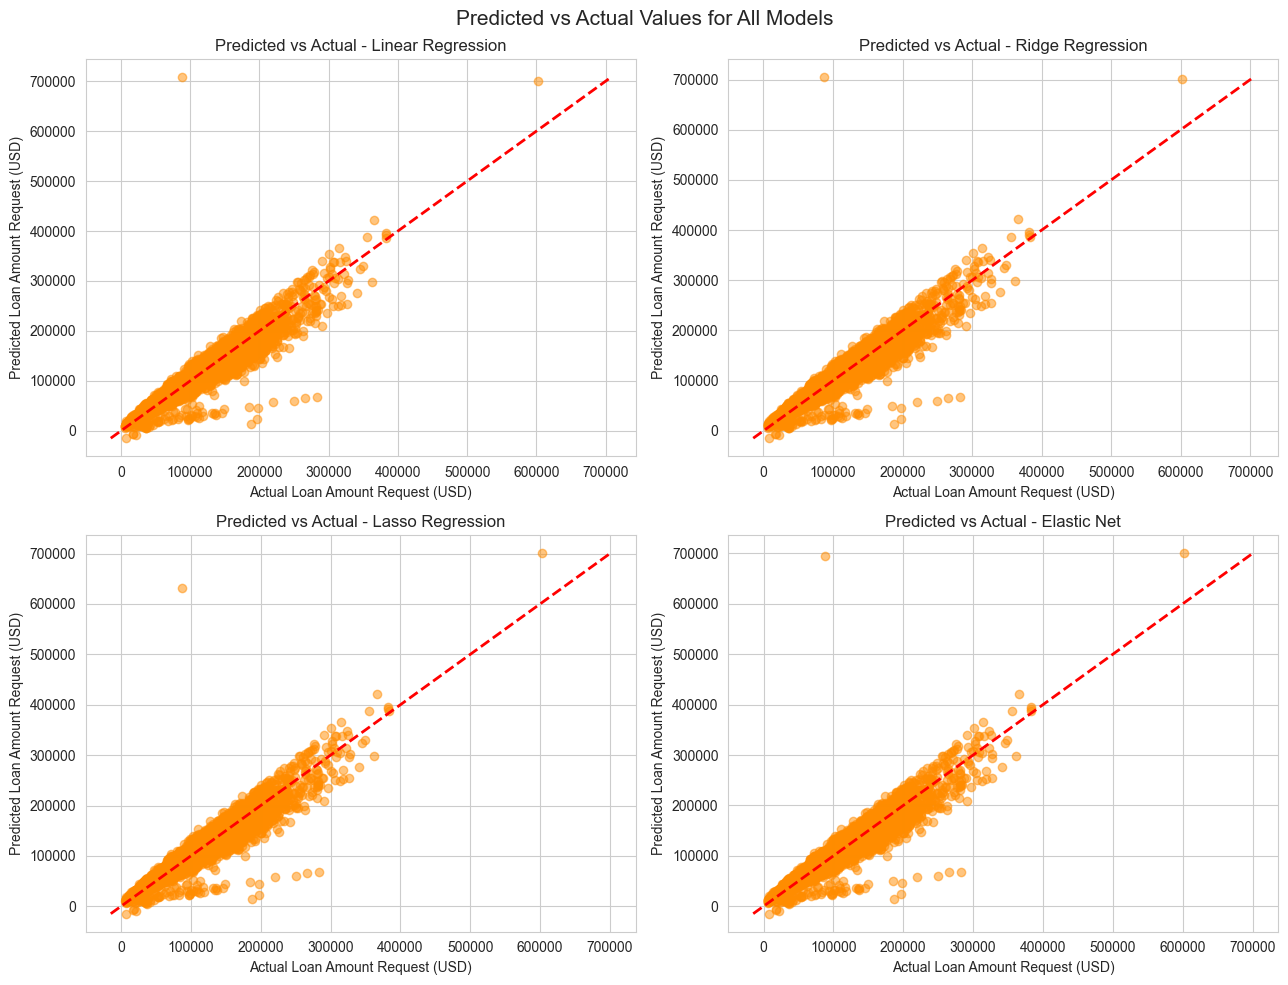

In [36]:
model_predictions = {
    "Linear Regression": y_test_pred_linear,
    "Ridge Regression": y_test_pred_ridge,
    "Lasso Regression": y_test_pred_lasso,
    "Elastic Net": y_test_pred_elastic
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (model_name, predictions) in enumerate(model_predictions.items()):
    axes[i].scatter(y_test, predictions, alpha=0.5, color="darkorange")

    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

    axes[i].set_title(f"Predicted vs Actual - {model_name}", fontsize=12)
    axes[i].set_xlabel("Actual " + TARGET_COLUMN)
    axes[i].set_ylabel("Predicted " + TARGET_COLUMN)

plt.suptitle("Predicted vs Actual Values for All Models", fontsize=15)
plt.tight_layout()
plt.show()


## 21. Residual Plot


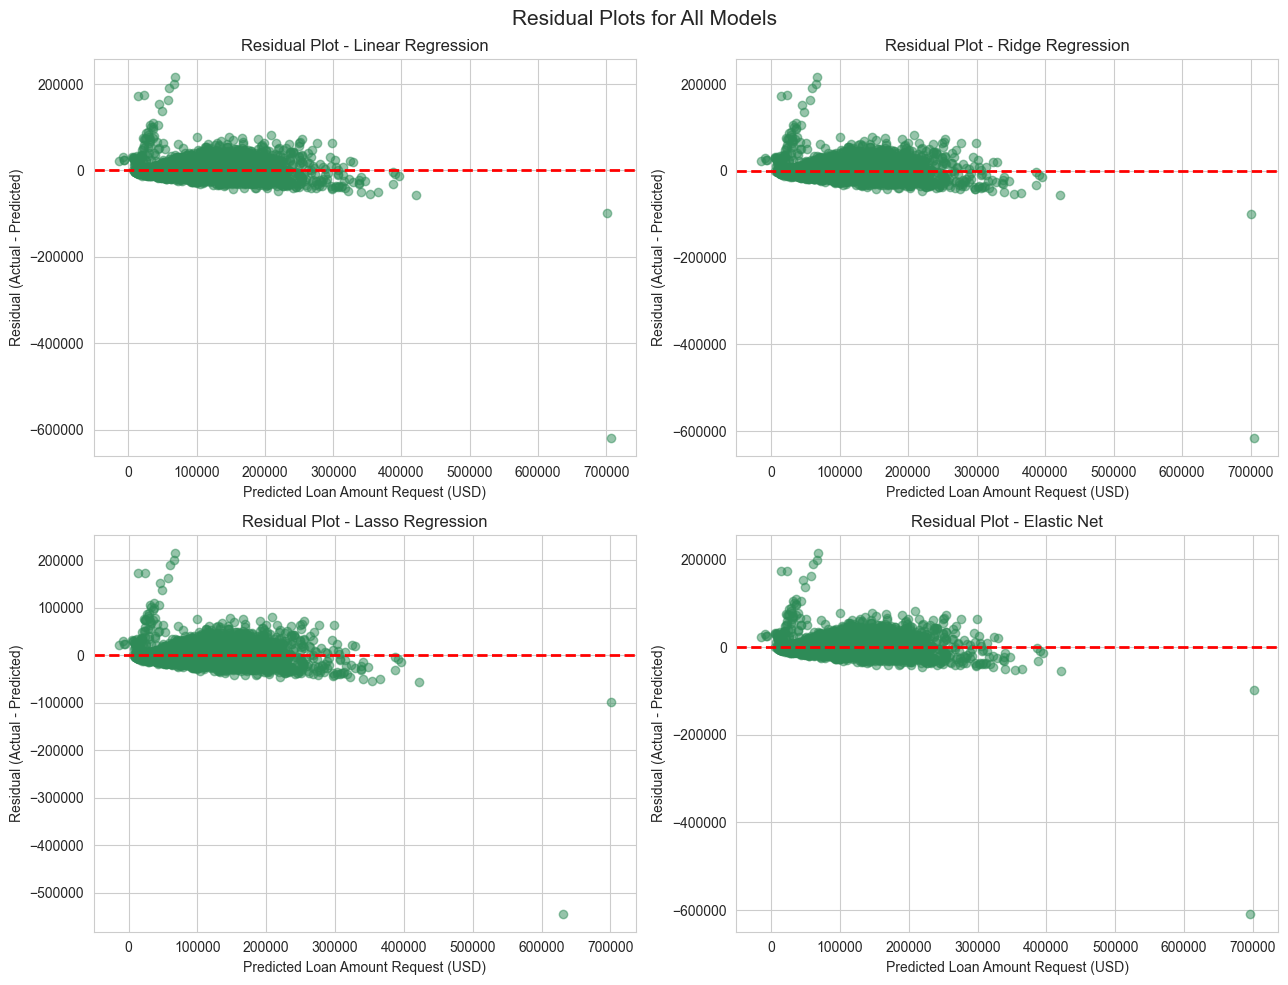

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (model_name, predictions) in enumerate(model_predictions.items()):
    residuals = y_test - predictions

    axes[i].scatter(predictions, residuals, alpha=0.5, color="seagreen")
    axes[i].axhline(y=0, color="red", linestyle="--", linewidth=2)

    axes[i].set_title(f"Residual Plot - {model_name}", fontsize=12)
    axes[i].set_xlabel("Predicted " + TARGET_COLUMN)
    axes[i].set_ylabel("Residual (Actual - Predicted)")

plt.suptitle("Residual Plots for All Models", fontsize=15)
plt.tight_layout()
plt.show()


## 22. Training Error vs Validation Error Plot


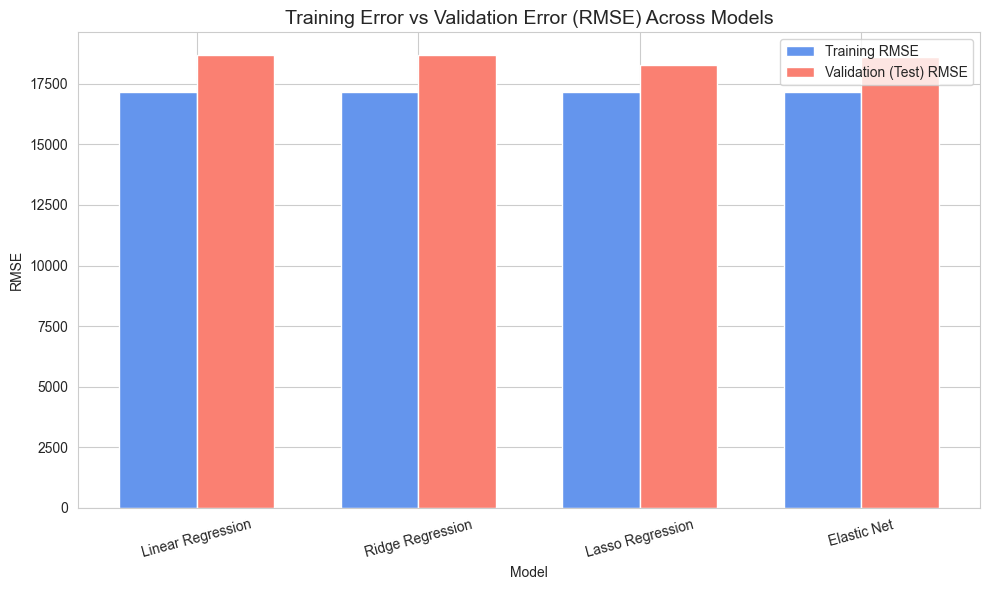

,Model,Training RMSE,Validation RMSE
0,Linear Regression,17177.926730,18685.101359
1,Ridge Regression,17177.973658,18667.496620
2,Lasso Regression,17178.115670,18290.212090
3,Elastic Net,17178.431575,18619.841516


In [38]:
train_predictions = {
    "Linear Regression": y_train_pred_linear,
    "Ridge Regression": y_train_pred_ridge,
    "Lasso Regression": y_train_pred_lasso,
    "Elastic Net": y_train_pred_elastic
}

model_names = list(model_predictions.keys())
train_rmse_values = [np.sqrt(mean_squared_error(y_train, train_predictions[name])) for name in model_names]
test_rmse_values = [np.sqrt(mean_squared_error(y_test, model_predictions[name])) for name in model_names]

x_positions = np.arange(len(model_names))
bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x_positions - bar_width/2, train_rmse_values, width=bar_width, label="Training RMSE", color="cornflowerblue")
plt.bar(x_positions + bar_width/2, test_rmse_values, width=bar_width, label="Validation (Test) RMSE", color="salmon")

plt.xticks(x_positions, model_names, rotation=15)
plt.title("Training Error vs Validation Error (RMSE) Across Models", fontsize=14)
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

# Print the values in a table
error_comparison_df = pd.DataFrame({
    "Model": model_names,
    "Training RMSE": train_rmse_values,
    "Validation RMSE": test_rmse_values
})
display(error_comparison_df)


## 23. Coefficient Comparison Plot



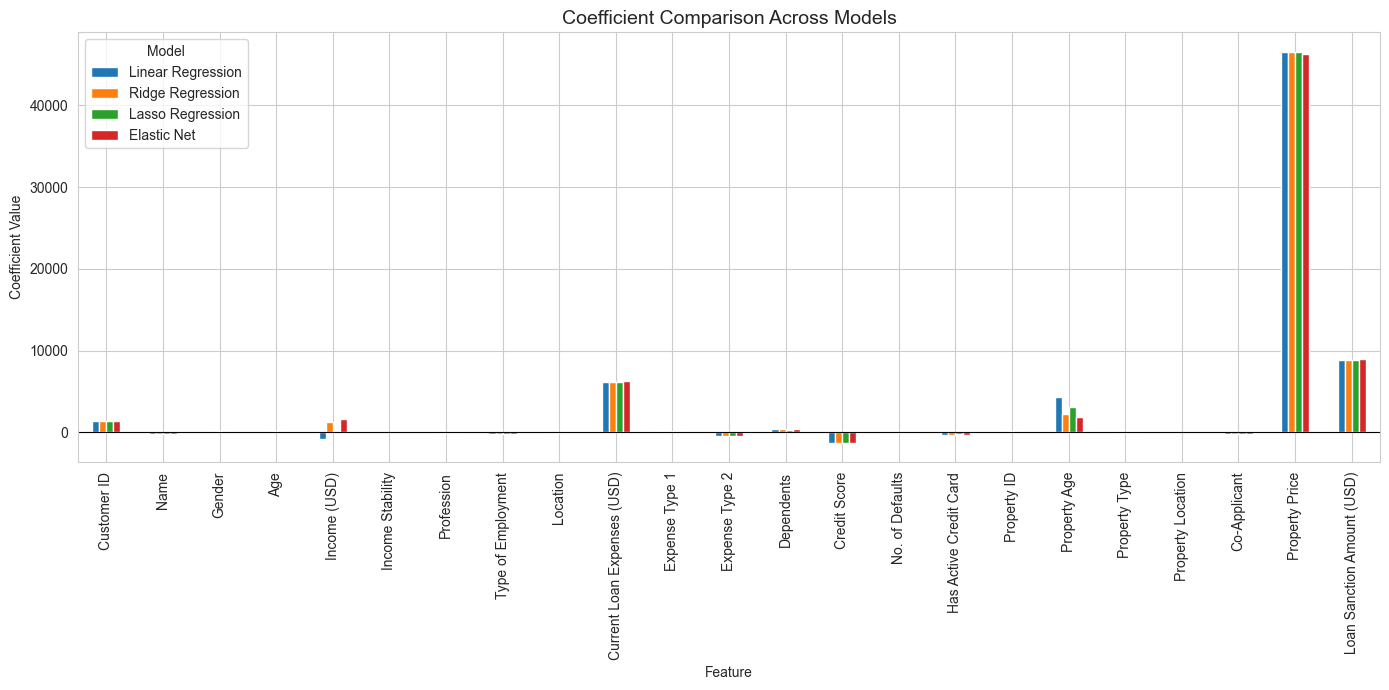

,Feature,Linear Regression,Ridge Regression,Lasso Regression,Elastic Net
0,Customer ID,1430.830090,1433.630927,1418.501813,1443.275677
1,Name,-152.068375,-151.779972,-142.456945,-151.433245
2,Gender,131.535746,131.606890,121.236435,131.992252
3,Age,170.389179,169.959295,151.398903,169.889577
4,Income (USD),-860.059537,1227.475042,0.000000,1593.728956
5,Income Stability,49.852607,50.274905,38.865843,52.159561
6,Profession,-37.779558,-38.592873,-28.766012,-42.000186
7,Type of Employment,-183.458543,-183.935323,-173.342850,-185.286385
8,Location,-19.627894,-19.439500,-0.251934,-16.827985
9,Current Loan Expenses (USD),6170.816761,6186.490462,6180.177699,6247.892926


In [39]:
coefficients_df = pd.DataFrame({
    "Feature": X_scaled.columns,
    "Linear Regression": linear_model.coef_,
    "Ridge Regression": ridge_best_model.coef_,
    "Lasso Regression": lasso_best_model.coef_,
    "Elastic Net": elastic_best_model.coef_
})

coefficients_df.set_index("Feature").plot(kind="bar", figsize=(14, 7))
plt.title("Coefficient Comparison Across Models", fontsize=14)
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.axhline(y=0, color="black", linewidth=0.8)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

display(coefficients_df)


## 24. Performance Comparison Table


In [40]:
# Convert results dictionary into a comparison DataFrame
performance_df = pd.DataFrame.from_dict(results, orient="index").round(4)
performance_df = performance_df.sort_values(by="R2", ascending=False)

print("Performance Comparison Table (sorted by R2 Score, best first):")
display(performance_df)

best_model_name = performance_df.index[0]
print(f"\nBased on R2 Score, the best performing model is: {best_model_name}")


Performance Comparison Table (sorted by R2 Score, best first):


,MAE,MSE,RMSE,R2,Training Time (s)
Lasso Regression,11346.2351,3.345319e+08,18290.2121,0.9043,1.5978
Elastic Net,11365.7532,3.466985e+08,18619.8415,0.9008,0.5837
Ridge Regression,11358.9479,3.484754e+08,18667.4966,0.9003,0.0075
Linear Regression,11357.0900,3.491330e+08,18685.1014,0.9001,0.0131



Based on R2 Score, the best performing model is: Lasso Regression
